# Statistics Advance-2 Assignment
### Data Science Masters - PW Skills

## Q1. What are PMF and PDF? Explain with an example.

**Probability Mass Function (PMF):**
- Used for **discrete** random variables.
- Gives the exact probability that a random variable takes a specific value.
- P(X = x) is a valid, non-zero probability.
- Sum of all PMF values = 1.

Example: Rolling a fair die. X = outcome.
P(X = 1) = P(X = 2) = ... = P(X = 6) = 1/6
This is the PMF of the die roll.

---

**Probability Density Function (PDF):**
- Used for **continuous** random variables.
- Does NOT give exact probability at a point — instead, the **area under the curve** between two points gives the probability.
- P(X = x) = 0 for any single point.
- Total area under PDF curve = 1.

Example: Height of people follows a Normal distribution. The PDF gives the density at each height value, and P(160 ≤ height ≤ 170) = area under the curve between 160 and 170.

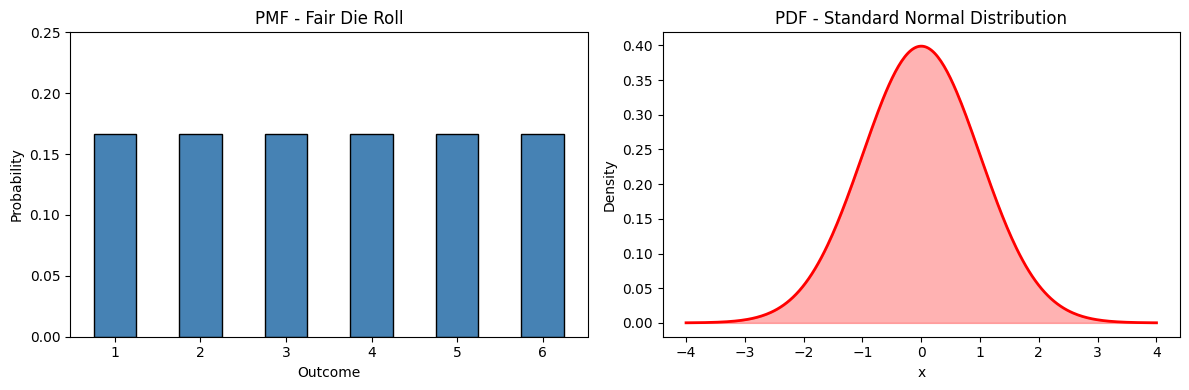

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PMF - Fair Die
x_pmf = np.arange(1, 7)
y_pmf = [1/6] * 6
axes[0].bar(x_pmf, y_pmf, color='steelblue', edgecolor='black', width=0.5)
axes[0].set_title('PMF - Fair Die Roll')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 0.25)

# PDF - Normal Distribution
x_pdf = np.linspace(-4, 4, 300)
y_pdf = norm.pdf(x_pdf, 0, 1)
axes[1].plot(x_pdf, y_pdf, 'r-', linewidth=2)
axes[1].fill_between(x_pdf, y_pdf, alpha=0.3, color='red')
axes[1].set_title('PDF - Standard Normal Distribution')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

## Q2. What is CDF? Explain with an example. Why CDF is used?

**Cumulative Distribution Function (CDF):**
- CDF gives the probability that a random variable X takes a value **less than or equal to** x.
- F(x) = P(X ≤ x)
- Works for both discrete and continuous distributions.
- CDF is always non-decreasing, starts at 0 and ends at 1.

**Example:**
For a fair die: F(3) = P(X ≤ 3) = P(1) + P(2) + P(3) = 1/6 + 1/6 + 1/6 = 0.5

**Why CDF is used?**
- To find probability in a range: P(a < X ≤ b) = F(b) - F(a)
- To find percentiles and quantiles
- Easier to compute cumulative probabilities than integrating PDF each time
- Used in hypothesis testing, confidence intervals, and statistical comparisons

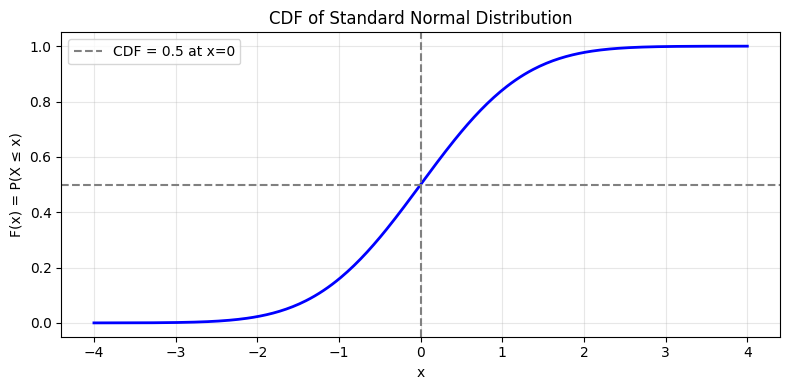

P(X ≤ 0)   = 0.5000
P(X ≤ 1.96)= 0.9750
P(0 < X ≤ 1) = 0.3413


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 300)
cdf = norm.cdf(x, 0, 1)

plt.figure(figsize=(8, 4))
plt.plot(x, cdf, 'b-', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', label='CDF = 0.5 at x=0')
plt.axvline(0, color='gray', linestyle='--')
plt.title('CDF of Standard Normal Distribution')
plt.xlabel('x')
plt.ylabel('F(x) = P(X ≤ x)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"P(X ≤ 0)   = {norm.cdf(0, 0, 1):.4f}")
print(f"P(X ≤ 1.96)= {norm.cdf(1.96, 0, 1):.4f}")
print(f"P(0 < X ≤ 1) = {norm.cdf(1,0,1) - norm.cdf(0,0,1):.4f}")

## Q3. Examples of Normal Distribution usage + how parameters affect shape

**Situations where Normal Distribution is used:**
1. Heights and weights of a population
2. IQ scores
3. Measurement errors in experiments
4. Blood pressure readings
5. Stock market returns (approximately)
6. Exam scores in large classes
7. Manufacturing defects (size/dimension variations)

**How parameters affect the shape:**

- **Mean (μ)** → controls the **center/location** of the bell curve. Shifting μ left or right moves the entire curve without changing its shape.

- **Standard Deviation (σ)** → controls the **spread/width** of the bell curve.
  - Small σ → tall, narrow, steep bell curve (data tightly packed around mean)
  - Large σ → short, wide, flat bell curve (data spread out)

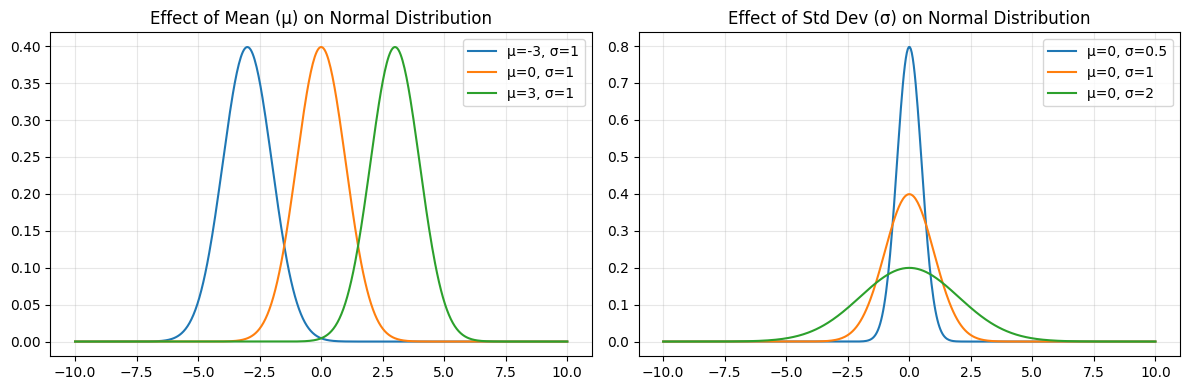

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-10, 10, 500)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Effect of mean
for mu in [-3, 0, 3]:
    axes[0].plot(x, norm.pdf(x, mu, 1), label=f'μ={mu}, σ=1')
axes[0].set_title('Effect of Mean (μ) on Normal Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Effect of std
for sigma in [0.5, 1, 2]:
    axes[1].plot(x, norm.pdf(x, 0, sigma), label=f'μ=0, σ={sigma}')
axes[1].set_title('Effect of Std Dev (σ) on Normal Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Q4. Importance of Normal Distribution + Real-life examples

**Importance of Normal Distribution:**

1. **Central Limit Theorem**: Sample means of any distribution tend to be normally distributed for large n — making normal distribution the foundation of inferential statistics.
2. **Symmetry**: Mean = Median = Mode, making analysis simpler.
3. **68-95-99.7 Rule**: 68% data within ±1σ, 95% within ±2σ, 99.7% within ±3σ — easy to interpret spread.
4. **Basis for many statistical tests**: t-test, z-test, ANOVA, linear regression all assume normality.
5. **Widely applicable**: Many natural and social phenomena follow it.

**Real-life examples:**
- Human heights: Average ~170cm, most people close to it, very few extremely tall/short
- IQ scores: Mean=100, SD=15, follows normal distribution
- Blood pressure readings in a healthy population
- Exam scores of a large student batch
- Daily temperature variations in a city
- Shoe sizes across a population
- Errors in manufacturing (e.g., bolt diameter variation)

## Q5. Bernoulli Distribution — Example + Difference from Binomial

**Bernoulli Distribution:**
- A distribution for a **single trial** with only two outcomes: Success (1) or Failure (0).
- Parameter: p = probability of success
- P(X=1) = p, P(X=0) = 1-p
- Mean = p, Variance = p(1-p)

**Example:** Flipping a coin once. X = 1 if Heads (p=0.5), X = 0 if Tails.

---

**Difference between Bernoulli and Binomial:**

| Feature | Bernoulli | Binomial |
|---|---|---|
| Number of trials | **1** (single trial) | **n** (multiple trials) |
| Outcomes | 0 or 1 | 0 to n (count of successes) |
| Parameters | p | n and p |
| Relation | Special case of Binomial | Sum of n Bernoulli trials |
| Example | One coin flip | 10 coin flips, count heads |

**Key**: Binomial(n=1, p) = Bernoulli(p)

## Q6. P(X > 60) for Normal(mean=50, std=10)

Z-score = (x - μ) / σ = (60 - 50) / 10 = 1.0
P(X > 60) = 1 - P(Z ≤ 1.0) = 1 - 0.8413 = 0.1587
P(X > 60) ≈ 15.87%


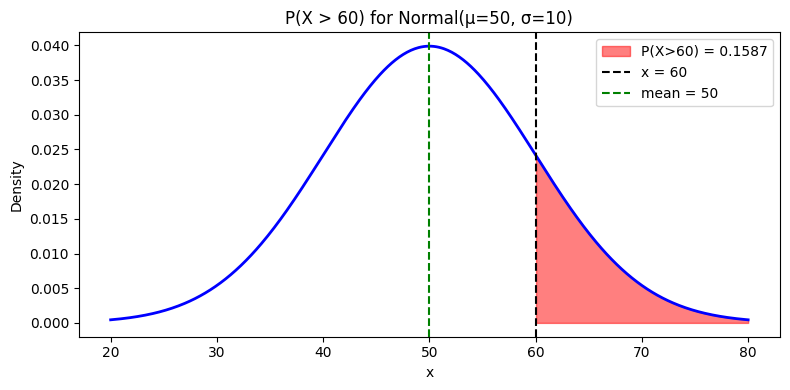

In [4]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

mean = 50
std  = 10
x_val = 60

# Z-score calculation
z = (x_val - mean) / std
print(f"Z-score = (x - μ) / σ = ({x_val} - {mean}) / {std} = {z}")

# P(X > 60) = 1 - P(X <= 60) = 1 - CDF(z)
prob = 1 - norm.cdf(z)
print(f"P(X > 60) = 1 - P(Z ≤ {z}) = 1 - {norm.cdf(z):.4f} = {prob:.4f}")
print(f"P(X > 60) ≈ {prob*100:.2f}%")

# Visualization
x = np.linspace(20, 80, 500)
y = norm.pdf(x, mean, std)

plt.figure(figsize=(8, 4))
plt.plot(x, y, 'b-', linewidth=2)
plt.fill_between(x, y, where=(x > 60), color='red', alpha=0.5, label=f'P(X>60) = {prob:.4f}')
plt.axvline(60, color='black', linestyle='--', label='x = 60')
plt.axvline(mean, color='green', linestyle='--', label=f'mean = {mean}')
plt.title('P(X > 60) for Normal(μ=50, σ=10)')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## Q7. Uniform Distribution with an example

**Uniform Distribution:**
- Every value in a given range [a, b] has an **equal probability** of occurring.
- Also called Rectangular Distribution.

**Types:**
1. **Discrete Uniform**: e.g., rolling a fair die — each of 1,2,3,4,5,6 has probability 1/6
2. **Continuous Uniform**: PDF = 1/(b-a) for a ≤ x ≤ b

**Parameters:** a (lower bound), b (upper bound)
- Mean = (a + b) / 2
- Variance = (b - a)² / 12

**Example:** A bus arrives every 30 minutes. If you arrive at a random time, your waiting time X ~ Uniform(0, 30). Every wait between 0 and 30 minutes is equally likely.

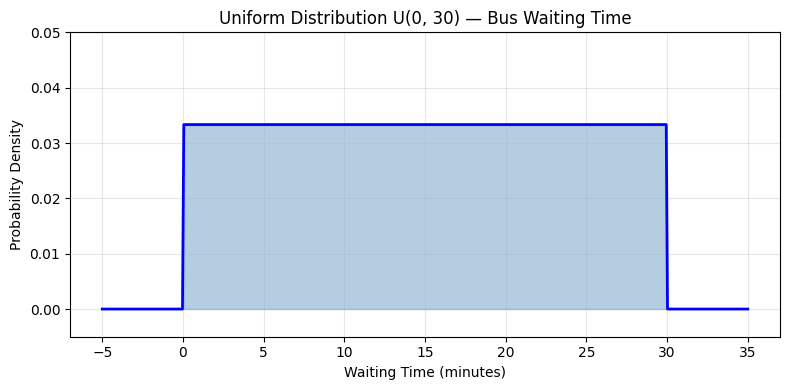

Mean     = (a+b)/2 = 15.0
Variance = (b-a)²/12 = 75.0000
P(10 ≤ X ≤ 20) = (20-10)/(30-0) = 0.3333


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

a, b = 0, 30
x = np.linspace(-5, 35, 500)
y = uniform.pdf(x, loc=a, scale=b-a)

plt.figure(figsize=(8, 4))
plt.plot(x, y, 'b-', linewidth=2)
plt.fill_between(x, y, where=((x >= a) & (x <= b)), color='steelblue', alpha=0.4)
plt.title('Uniform Distribution U(0, 30) — Bus Waiting Time')
plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Probability Density')
plt.ylim(-0.005, 0.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean     = (a+b)/2 = {(a+b)/2}")
print(f"Variance = (b-a)²/12 = {(b-a)**2/12:.4f}")
print(f"P(10 ≤ X ≤ 20) = (20-10)/(30-0) = {10/30:.4f}")

## Q8. What is Z-score? State its importance.

**Z-score (Standard Score):**
- Z-score tells how many standard deviations a data point is away from the mean.
- Formula: **Z = (X - μ) / σ**
  - X = data point
  - μ = mean
  - σ = standard deviation

**Importance of Z-score:**
1. **Standardization**: Converts any normal distribution to Standard Normal (mean=0, std=1) — making distributions comparable.
2. **Outlier Detection**: |Z| > 3 is generally considered an outlier.
3. **Probability Calculation**: Use Z-tables to find probability for any normal distribution.
4. **Comparison across different scales**: e.g., comparing a student's performance in Math vs English when scoring scales differ.
5. **Basis for hypothesis testing**: Z-test directly uses Z-scores.
6. **Feature Scaling in ML**: Z-score normalization (StandardScaler) is widely used.

In [6]:
import numpy as np

# Example: student scored 75 in a class with mean=60, std=10
x   = 75
mu  = 60
std = 10

z = (x - mu) / std
print(f"Score = {x}, Mean = {mu}, Std = {std}")
print(f"Z-score = ({x} - {mu}) / {std} = {z}")
print(f"The student scored {z} standard deviations ABOVE the mean.")

# Another example for negative z-score
x2 = 50
z2 = (x2 - mu) / std
print(f"\nScore = {x2} → Z = {z2} (1 std below mean)")

Score = 75, Mean = 60, Std = 10
Z-score = (75 - 60) / 10 = 1.5
The student scored 1.5 standard deviations ABOVE the mean.

Score = 50 → Z = -1.0 (1 std below mean)


## Q9. What is Central Limit Theorem? State its significance.

**Central Limit Theorem (CLT):**
- States that if you take sufficiently large random samples (n ≥ 30) from **any population** (regardless of its original distribution), the distribution of **sample means** will be approximately **Normal**.
- Sample mean distribution: X̄ ~ Normal(μ, σ²/n)
  - Mean of sample means = μ (population mean)
  - Std of sample means = σ/√n (standard error)

**Significance of CLT:**
1. **Foundation of inferential statistics** — allows us to make conclusions about populations from samples.
2. Works for **any distribution** (uniform, skewed, exponential, etc.) — very powerful and general.
3. Justifies the use of **z-tests and t-tests** even when the population is not normal.
4. Enables construction of **confidence intervals**.
5. As sample size increases, sample mean estimates become more **precise** (std error shrinks).

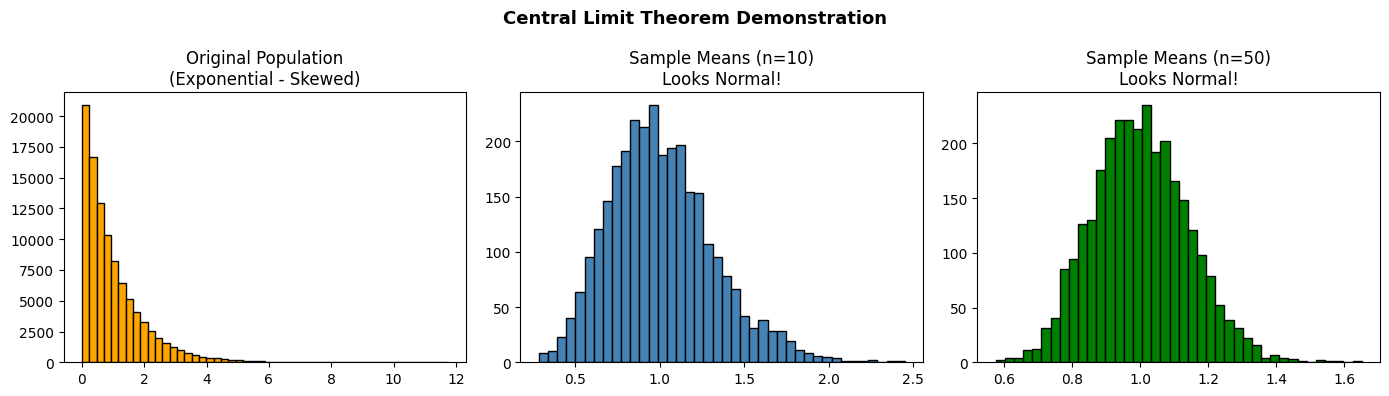

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Population: Exponential distribution (heavily skewed, NOT normal)
population = np.random.exponential(scale=1, size=100000)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Original population
axes[0].hist(population, bins=50, color='orange', edgecolor='black')
axes[0].set_title('Original Population\n(Exponential - Skewed)')

# Sample means for different n
for ax, n, color in zip(axes[1:], [10, 50], ['steelblue', 'green']):
    sample_means = [np.random.choice(population, n).mean() for _ in range(3000)]
    ax.hist(sample_means, bins=40, color=color, edgecolor='black')
    ax.set_title(f'Sample Means (n={n})\nLooks Normal!')

plt.suptitle('Central Limit Theorem Demonstration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Q10. Assumptions of the Central Limit Theorem

**Assumptions of the Central Limit Theorem:**

1. **Independence**: Each sample observation must be independent of others. (Sampling with replacement, or n < 10% of population for without-replacement)

2. **Random Sampling**: Samples must be drawn randomly from the population — no bias in selection.

3. **Finite Mean and Variance**: The population must have a finite mean (μ) and finite variance (σ²). (Distributions like Cauchy violate this and CLT does NOT apply)

4. **Sample Size**: The sample size should be sufficiently large.
   - General rule: **n ≥ 30** is considered large enough.
   - For highly skewed distributions, even larger n may be needed.
   - For already-normal populations, even small n works.

5. **Identically Distributed** (in the classical form): Each sample comes from the same population distribution (i.e., i.i.d. — independent and identically distributed).